# 03 - E91 ideale e test CHSH


In questo notebook simuliamo il protocollo E91 ideale e il test CHSH associato allo stato entangled.

E91 usa coppie entangled condivise tra Alice e Bob. Nei round in cui Alice e Bob scelgono la stessa base si ottiene la chiave sifted.

Nel caso ideale il QBER sulla chiave sifted ? 0. La violazione CHSH mostra correlazioni non spiegabili da un modello classico locale: il limite classico ? |S| <= 2, mentre il limite quantistico ideale ? vicino a 2?2.

## Setup

Prepariamo gli import, aggiungiamo `src` al path e creiamo le cartelle in cui salvare tabelle e figure.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

current_path = Path.cwd()

if (current_path / "src" / "e91.py").exists():
    project_root = current_path
else:
    project_root = current_path.parent

src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from e91 import run_e91_protocol, run_chsh_experiment
from qkd_core import sift_keys, compute_qber
from metrics import (
    CHSH_CLASSICAL_LIMIT,
    CHSH_TSIRELSON_BOUND,
    compute_sifted_key_length,
    compute_sifted_key_rate,
)

tables_dir = project_root / "results" / "tables"
figures_dir = project_root / "results" / "figures"

tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

print("Setup completato.")

Setup completato.


## Parametri

Impostiamo il numero di round E91, il numero di shot per CHSH e il seed della simulazione.

In [2]:
N_ROUNDS = 1000
SHOTS_CHSH = 2000
SEED = 42

print("Numero di round E91:", N_ROUNDS)
print("Shot CHSH:", SHOTS_CHSH)
print("Seed:", SEED)

Numero di round E91: 1000
Shot CHSH: 2000
Seed: 42


## Esecuzione E91 ideale

Eseguiamo il protocollo E91 ideale, applichiamo il sifting e calcoliamo il QBER.

In [3]:
results = run_e91_protocol(N_ROUNDS, seed=SEED)

alice_key, bob_key = sift_keys(results)
qber = compute_qber(alice_key, bob_key)

print("Lunghezza chiave Alice dopo sifting:", len(alice_key))
print("Lunghezza chiave Bob dopo sifting:", len(bob_key))
print("QBER:", qber)

Lunghezza chiave Alice dopo sifting: 489
Lunghezza chiave Bob dopo sifting: 489
QBER: 0.0


## Tabella dei round

Convertiamo la lista dei risultati in una tabella pandas e salviamo tutti i round in formato CSV.

In [4]:
df = pd.DataFrame(results)

rounds_path = tables_dir / "e91_ideal_rounds.csv"
df.to_csv(rounds_path, index=False)

print(f"Tabella dei round salvata in: {rounds_path}")
df.head(10)

Tabella dei round salvata in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\e91_ideal_rounds.csv


,round,alice_basis,bob_basis,alice_bit,bob_bit,keep
0,1,Z,X,1,1,False
1,2,X,X,0,0,True
2,3,X,Z,0,0,False
3,4,Z,Z,0,0,True
4,5,Z,X,0,1,False
5,6,X,Z,0,1,False
6,7,Z,Z,0,0,True
7,8,X,X,0,0,True
8,9,Z,Z,1,1,True
9,10,Z,X,0,0,False


## Sintesi numerica E91

Raccogliamo le metriche principali della simulazione E91 ideale in una tabella riassuntiva.

In [5]:
sifted_key_length = compute_sifted_key_length(alice_key)
sifted_key_rate = compute_sifted_key_rate(alice_key, N_ROUNDS)

summary = {
    "protocol": "E91 ideal",
    "n_rounds": N_ROUNDS,
    "sifted_key_length": sifted_key_length,
    "sifted_key_rate": sifted_key_rate,
    "qber": qber,
    "seed": SEED,
}

summary_df = pd.DataFrame([summary])

summary_path = tables_dir / "e91_ideal_summary.csv"
summary_df.to_csv(summary_path, index=False)

print(f"Sintesi E91 salvata in: {summary_path}")
summary_df

Sintesi E91 salvata in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\e91_ideal_summary.csv


,protocol,n_rounds,sifted_key_length,sifted_key_rate,qber,seed
0,E91 ideal,1000,489,0.489,0.0,42


## Grafico keep/discard

Visualizziamo quanti round vengono mantenuti e quanti vengono scartati dopo il confronto delle basi.

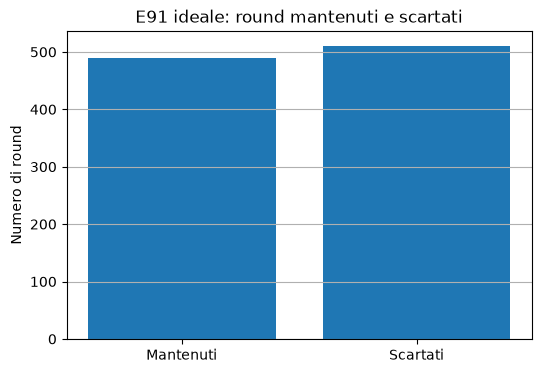

Round mantenuti: 489
Round scartati: 511
Grafico keep/discard salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\e91_ideal_keep_discard.png


In [6]:
kept_rounds = 0
discarded_rounds = 0

for i in range(len(results)):
    if results[i]["keep"] == True:
        kept_rounds += 1
    else:
        discarded_rounds += 1

labels = ["Mantenuti", "Scartati"]
values = [kept_rounds, discarded_rounds]

plt.figure(figsize=(6, 4))
plt.bar(labels, values)
plt.ylabel("Numero di round")
plt.title("E91 ideale: round mantenuti e scartati")
plt.grid(axis="y")

keep_discard_path = figures_dir / "e91_ideal_keep_discard.png"
plt.savefig(keep_discard_path, dpi=300, bbox_inches="tight")
plt.show()

print("Round mantenuti:", kept_rounds)
print("Round scartati:", discarded_rounds)
print(f"Grafico keep/discard salvato in: {keep_discard_path}")

## Esperimento CHSH ideale

Eseguiamo il test CHSH sullo stato entangled ideale usato dal protocollo E91.

In [7]:
chsh_result = run_chsh_experiment(
    shots=SHOTS_CHSH,
    seed=SEED,
)

chsh_summary = {
    "scenario": "E91 ideal",
    "shots": SHOTS_CHSH,
    "E_ab": chsh_result["E_ab"],
    "E_ab_prime": chsh_result["E_ab_prime"],
    "E_a_prime_b": chsh_result["E_a_prime_b"],
    "E_a_prime_b_prime": chsh_result["E_a_prime_b_prime"],
    "S": chsh_result["S"],
    "abs_S": chsh_result["abs_S"],
    "violates_chsh": chsh_result["violates_chsh"],
    "chsh_gap": chsh_result["chsh_gap"],
    "chsh_strength": chsh_result["chsh_strength"],
    "seed": SEED,
}

chsh_df = pd.DataFrame([chsh_summary])

chsh_path = tables_dir / "e91_ideal_chsh_summary.csv"
chsh_df.to_csv(chsh_path, index=False)

print(f"Sintesi CHSH salvata in: {chsh_path}")
chsh_df

Sintesi CHSH salvata in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\e91_ideal_chsh_summary.csv


,scenario,shots,E_ab,E_ab_prime,E_a_prime_b,E_a_prime_b_prime,S,abs_S,violates_chsh,chsh_gap,chsh_strength,seed
0,E91 ideal,2000,0.691,0.717,0.671,-0.738,2.817,2.817,True,0.817,0.986206,42


## Grafico CHSH

Rappresentiamo il valore simulato di |S| come una sola barra. I limiti classico e quantistico sono mostrati come linee tratteggiate, perch? sono valori teorici di riferimento e non risultati sperimentali.

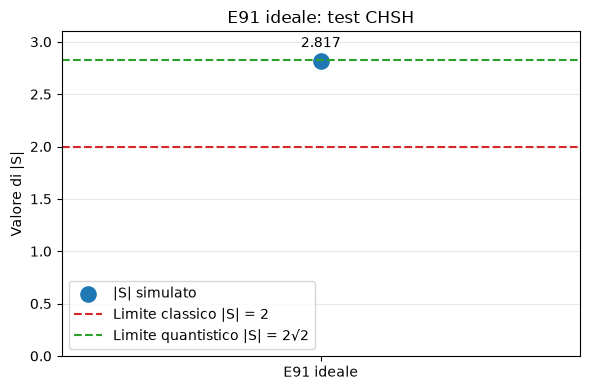

|S| simulato: 2.8169999999999997
Limite classico: 2.0
Limite quantistico: 2.8284271247461903
Grafico CHSH salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\e91_ideal_chsh.png


In [8]:
abs_s = chsh_result["abs_S"]

fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(
    ["E91 ideale"],
    [abs_s],
    s=120,
    color="tab:blue",
    label="|S| simulato",
)

ax.axhline(
    CHSH_CLASSICAL_LIMIT,
    color="tab:red",
    linestyle="--",
    label="Limite classico |S| = 2",
)

ax.axhline(
    CHSH_TSIRELSON_BOUND,
    color="tab:green",
    linestyle="--",
    label="Limite quantistico |S| = 2√2",
)

ax.annotate(
    f"{abs_s:.3f}",
    xy=("E91 ideale", abs_s),
    xytext=(0, 10),
    textcoords="offset points",
    ha="center",
)

ax.set_title("E91 ideale: test CHSH")
ax.set_ylabel("Valore di |S|")
ax.set_ylim(0, 3.1)
ax.grid(axis="y", alpha=0.3)
ax.legend()

fig.tight_layout()

chsh_figure_path = figures_dir / "e91_ideal_chsh.png"
fig.savefig(chsh_figure_path, dpi=300)
plt.show()

print("|S| simulato:", abs_s)
print("Limite classico:", CHSH_CLASSICAL_LIMIT)
print("Limite quantistico:", CHSH_TSIRELSON_BOUND)
print(f"Grafico CHSH salvato in: {chsh_figure_path}")

## Commento finale

Nel caso ideale il QBER ? nullo. Il sifted key rate ? circa 0.5 perch? Alice e Bob scelgono casualmente tra le basi `Z` e `X`.

Il parametro |S| supera il limite classico 2, mostrando una correlazione non spiegabile con una semplice correlazione classica locale.

Nei notebook successivi si confronteranno gli effetti di Eve, della sorgente classica e del rumore.